In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/placement/placement.csv


In [3]:
placement = pd.read_csv("/kaggle/input/placement/placement.csv")

placement

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


In [4]:
import matplotlib.pyplot as plt


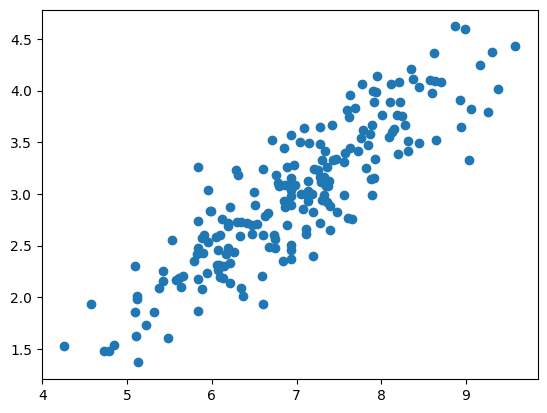

In [5]:
plt.scatter(placement["cgpa"] , placement["package"])

In [6]:
x = placement["cgpa"]

y = placement["package"]

y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [7]:
from sklearn.model_selection import train_test_split

x_train , x_test,y_train , y_test = train_test_split(x , y , test_size = 0.3 , random_state = 2)

In [8]:
y_train = np.array(y_train.to_list())
x_train = np.array(x_train.to_list())

In [9]:
y_train = y_train.reshape(-1,1)
x_train = x_train.reshape(-1,1)

In [10]:
from sklearn.linear_model import LinearRegression


In [11]:
lr = LinearRegression()

lr

LinearRegression()

In [12]:
lr.fit(x_train , y_train)

LinearRegression()

In [13]:
x_test

112    8.58
29     7.15
182    5.88
199    6.22
193    4.57
85     4.79
10     5.32
54     6.86
115    8.35
35     6.87
12     8.94
92     7.90
13     6.93
126    5.91
174    7.32
2      7.82
44     5.09
3      7.42
113    6.94
14     7.73
23     6.19
25     7.28
6      6.73
134    7.20
165    8.21
173    6.75
45     7.87
65     7.60
48     8.63
122    5.12
178    8.15
64     7.36
9      8.31
57     6.60
78     6.59
71     7.47
128    7.93
176    6.29
131    6.37
53     6.47
137    7.14
163    8.93
111    5.42
123    5.10
109    7.77
141    6.76
41     6.89
130    6.68
140    7.91
5      7.89
159    8.71
100    7.95
11     6.61
187    6.26
24     6.53
89     6.42
66     5.11
8      6.09
172    6.93
175    7.04
Name: cgpa, dtype: float64

In [14]:
y_test

112    4.10
29     3.49
182    2.08
199    2.33
193    1.94
85     1.48
10     1.86
54     3.09
115    4.21
35     2.87
12     3.65
92     4.00
13     2.89
126    2.60
174    2.99
2      3.25
44     1.86
3      3.67
113    2.37
14     3.42
23     2.48
25     3.65
6      2.60
134    2.83
165    4.08
173    2.56
45     3.58
65     3.81
48     4.09
122    2.01
178    3.63
64     2.92
9      3.51
57     1.94
78     2.21
71     3.34
128    3.34
176    3.23
131    2.01
53     2.61
137    3.13
163    3.91
111    2.25
123    2.30
109    4.06
141    3.18
41     2.70
130    2.49
140    3.15
5      2.99
159    4.08
100    4.14
11     2.60
187    2.44
24     2.71
89     2.72
66     1.63
8      2.31
172    2.51
175    3.50
Name: package, dtype: float64

In [15]:
x_test[122]

5.12

In [16]:
lr.predict(x_test[122].reshape(1,1))

array([[1.9672833]])

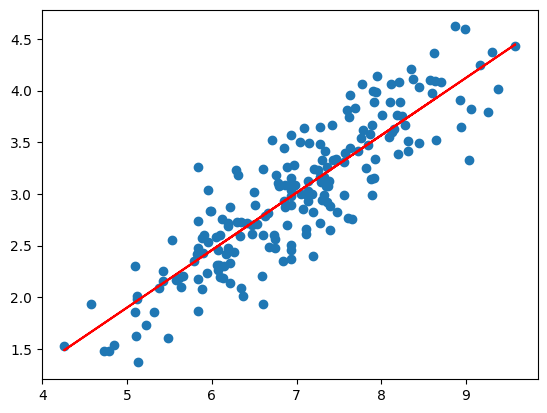

In [17]:
plt.scatter(placement["cgpa"] , placement["package"])
plt.plot(x_train , lr.predict(x_train) , color="red")

plt.show()

In [18]:
slope = lr.coef_

In [19]:
intercept = lr.intercept_
intercept

array([-0.87811784])

In [21]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

In [27]:
y_pred = lr.predict(np.array(x_test.to_list()).reshape(-1 , 1))

In [28]:
print("MAE" , mean_absolute_error(y_test , y_pred))

MAE 0.28749100679609285


In [29]:
print("MSE"  ,mean_squared_error(y_test , y_pred))

MSE 0.11858895151249156


In [30]:
print("RMSE"  ,np.sqrt(mean_squared_error(y_test , y_pred)))

RMSE 0.34436746581593847


In [32]:
print("R2"  ,r2_score(y_test , y_pred))

R2 0.7736419609402848
